# SUPPORT2 Dataset: Exploratory Data Analysis
**AAI-500 Applied Statistics for AI | Final Team Project**

---

## Notebook Objectives

This notebook covers the **Exploratory Data Analysis** phase of the project pipeline:

1. Detect Outliers
1. Univariate Analysis
1. Bivariate Analsysis
1. Demographic Analsysis
1. Disease Group Analysis
1. DNR Status Analysis

# 

---
# Learnings from the 1990s study
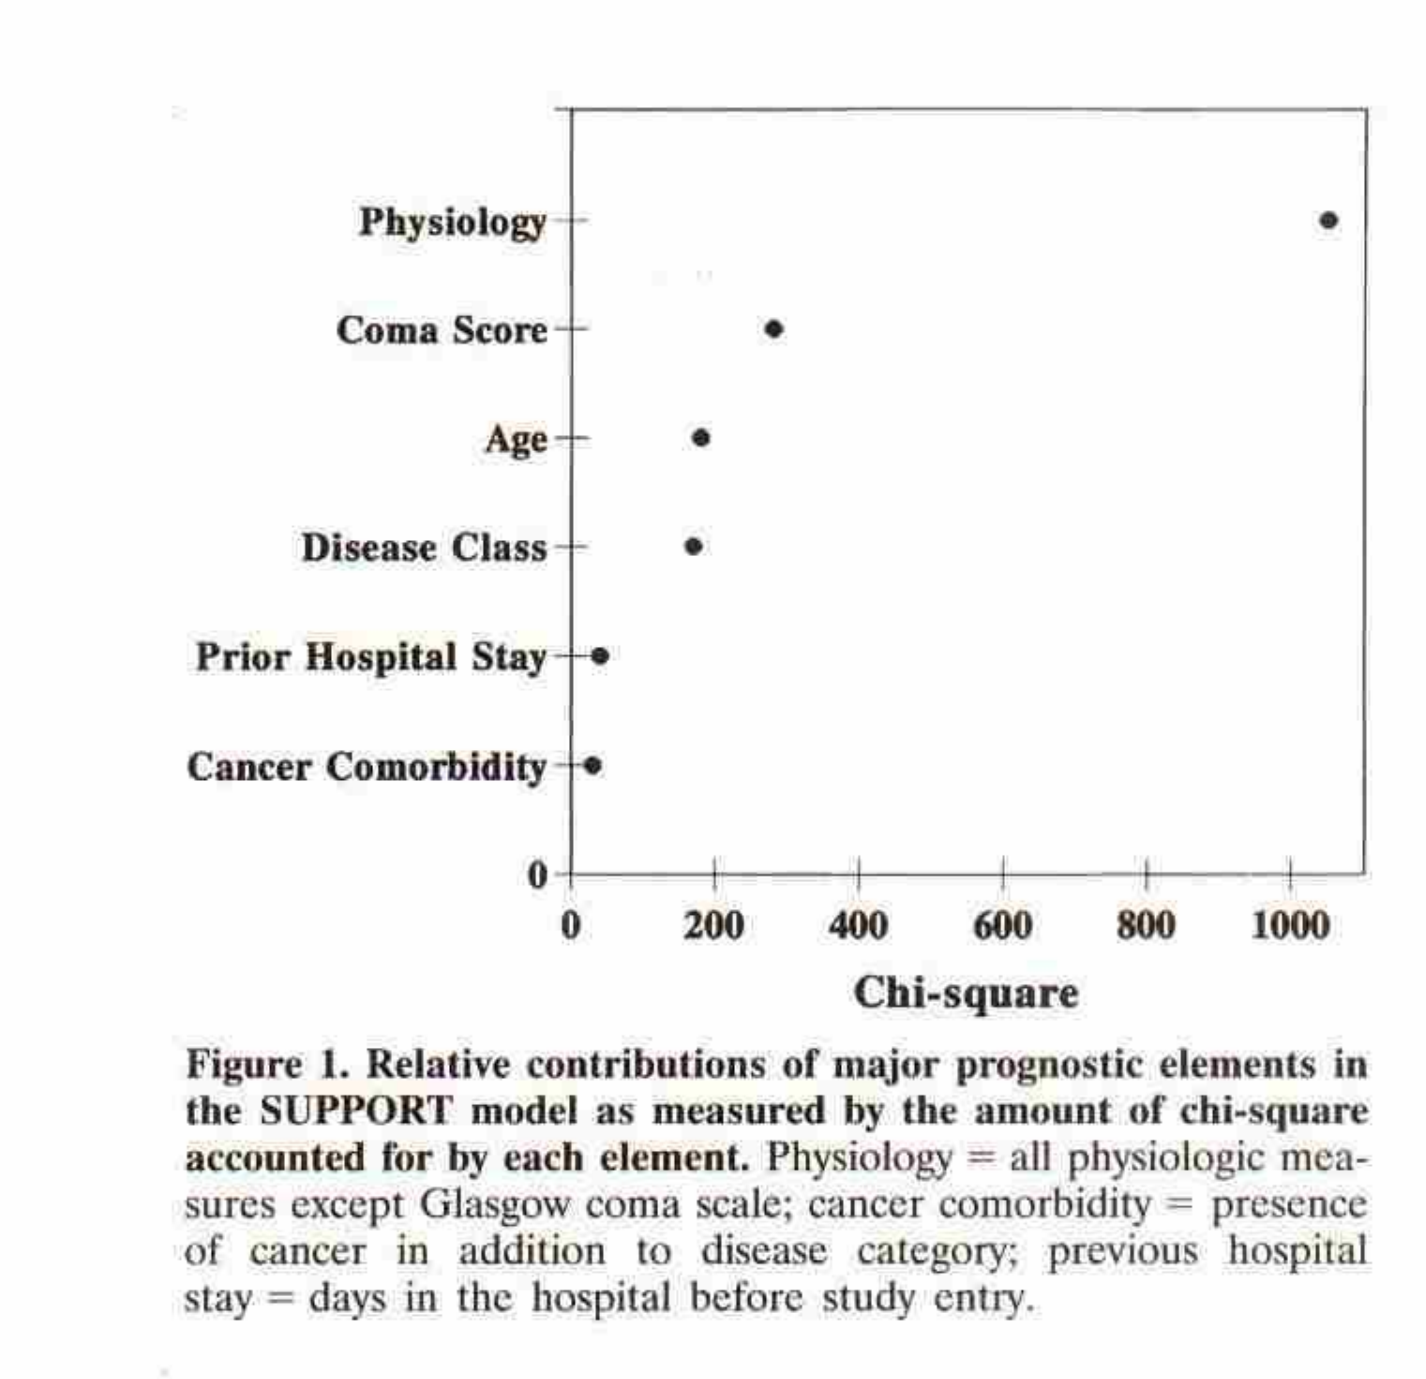
To inform our work, we review Knaus et al's (1995) paper.
According to Knaus et al these features were most weighted in their model:
- Physiology Score (calculated from wbc, albumin, etc). Some salient ones are Blood Pressure and Oxygenation levels
- Neurological Function (Glasgow coma scale)
- Patient age (but only when coupled with certain diseases like COPD)
- Apache III score
- Disease-Specific Interactions: The mathematical weight of certain features was explicitly programmed to vary based on the patient's primary disease:Albumin x Disease: A low albumin level strongly predicted death in cancer, COPD, and congestive heart failure, but was relatively unimportant in coma or MOSF.  WBC x Disease: A low WBC count was specifically associated with a greater risk of death in acute respiratory failure and MOSF.  Age x Disease: Advancing age heavily impacted short-term survival in COPD but had almost no incremental effect on patients with severe acute complications like MOSF or malignancy.  

---
## Section 0: Setup & Imports

In [31]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

_here = Path.cwd()
_proj_root = _here if (_here / "utils").exists() else (_here / "../..").resolve()
if str(_proj_root) not in sys.path:
    sys.path.insert(0, str(_proj_root))

from utils.dataset import load_csv  # noqa: E402

warnings.filterwarnings("ignore")

---
## Section 1: Load Cleaned Data

In [32]:
df = load_csv("support2_cleaned.csv")
print(f"Shape: {df.shape[0]:,} rows  x  {df.shape[1]} columns")

OUTCOME_COLS = ["death", "hospdead", "d_time", "slos"]
ID_COLS = ["id"]
TARGET_COL = "death_180d"
BENCHMARK_COLS = ["surv2m", "surv6m", "aps", "sps", "prg2m", "prg6m", "dnr"]
LAB_COLS = [
    "meanbp",
    "wblc",
    "hrt",
    "resp",
    "temp",
    "pafi",
    "alb",
    "bili",
    "crea",
    "sod",
    "ph",
    "glucose",
    "bun",
    "urine",
]
FEATURE_COLS = [
    c
    for c in df.columns
    if c not in OUTCOME_COLS + ID_COLS + [TARGET_COL] + BENCHMARK_COLS
]

survivors = df[df[TARGET_COL] == 0]
died = df[df[TARGET_COL] == 1]
overall_rate = df[TARGET_COL].mean()
print(f"Survived 180d   : {len(survivors):,}  ({1 - overall_rate:.1%})")
print(f"Died within 180d: {len(died):,}  ({overall_rate:.1%})")

Shape: 9,002 rows  x  46 columns
Survived 180d   : 4,804  (53.4%)
Died within 180d: 4,198  (46.6%)


---
## Section 2: Physiology Outlier Detection (IQR Method)

```
IQR = Q3 - Q1
Lo whisker = Q1 - 1.5IQR
Hi whisker = Q3 + 1.5IQR
```

- Urine boxplot median is pushed all the way right because of imputation with Norm-Fill. 
- Glucose boxplot collapses due to high number of imputed NAs.
- **Probably better to run outliers before imputation**

In [33]:
def compute_iqr_outliers(df, cols):
    rows = []
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        outliers = int(((df[col] < lo) | (df[col] > hi)).sum())
        rows.append(
            {
                "Column": col,
                "Q1": round(float(Q1), 3),
                "Q3": round(float(Q3), 3),
                "IQR": round(float(IQR), 3),
                "Lo Whisker": round(float(lo), 3),
                "Hi Whisker": round(float(hi), 3),
                "Outliers": outliers,
                "Outlier %": round(outliers / len(df) * 100, 1),
            }
        )
    return pd.DataFrame(rows).sort_values("Outlier %", ascending=False)


outlier_df = compute_iqr_outliers(df, LAB_COLS)
print(
    outlier_df[
        ["Column", "Lo Whisker", "Hi Whisker", "Outliers", "Outlier %"]
    ].to_string(index=False)
)

 Column  Lo Whisker  Hi Whisker  Outliers  Outlier %
glucose     128.875     139.875      4295       47.7
  urine    1473.875    3118.875      2384       26.5
   bili      -0.450       2.350      1378       15.3
     ph       7.325       7.524      1065       11.8
   crea      -0.600       3.400       954       10.6
    bun     -19.725      50.235       898       10.0
   wblc      -5.149      27.249       420        4.7
   resp       3.000      43.000       247        2.7
    sod     123.500     151.500       245        2.7
   pafi     -49.950     563.250        59        0.7
    alb       1.150       4.750        66        0.7
    hrt       0.000     192.000        40        0.4
   temp      33.348      40.941        22        0.2
 meanbp      -0.500     171.500         9        0.1


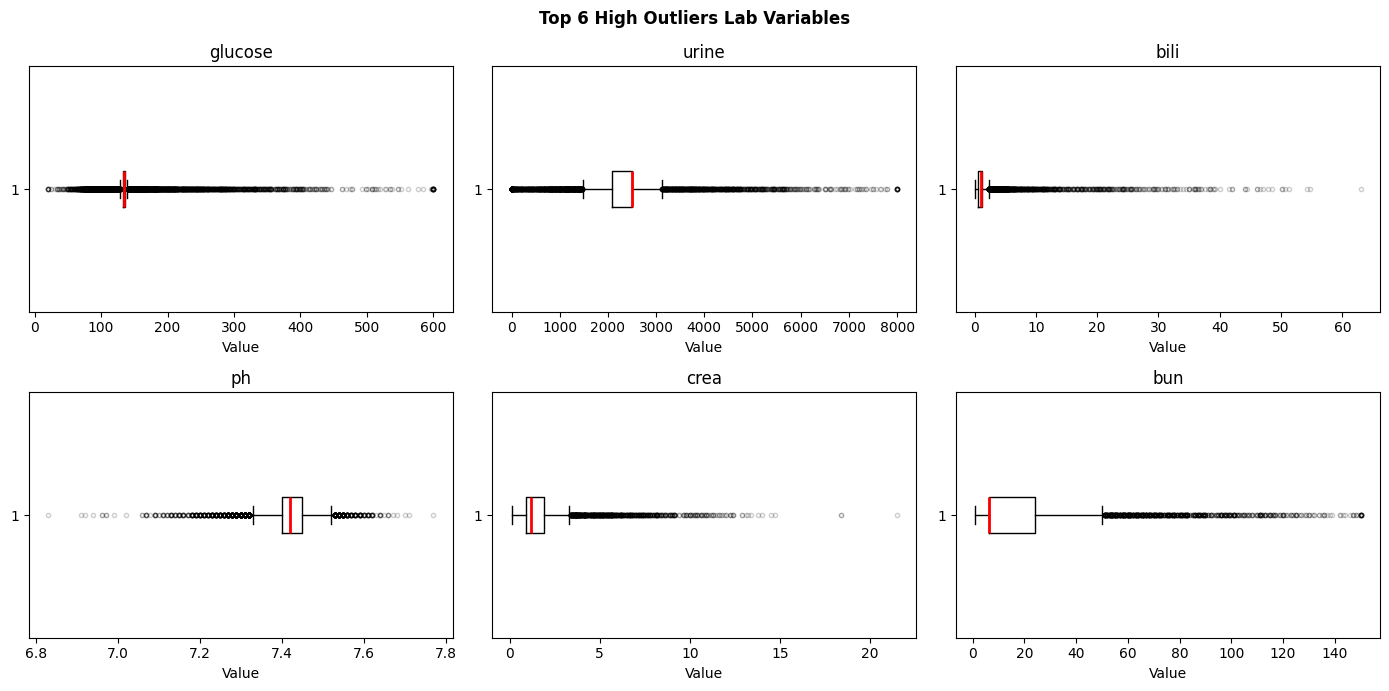

In [34]:
top6 = outlier_df.head(6)["Column"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for i, col in enumerate(top6):
    axes.flat[i].boxplot(
        df[col],
        vert=False,
        medianprops=dict(color="red", linewidth=2),
        flierprops=dict(marker="o", alpha=0.2, markersize=3, color="gray"),
    )
    axes.flat[i].set_title(col)
    axes.flat[i].set_xlabel("Value")
fig.suptitle("Top 6 High Outliers Lab Variables", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Section 3: Univariate Distributions

- Lab features are mainly right skewed
- Some imputations cause spikeness (glucose, pafi, bili)

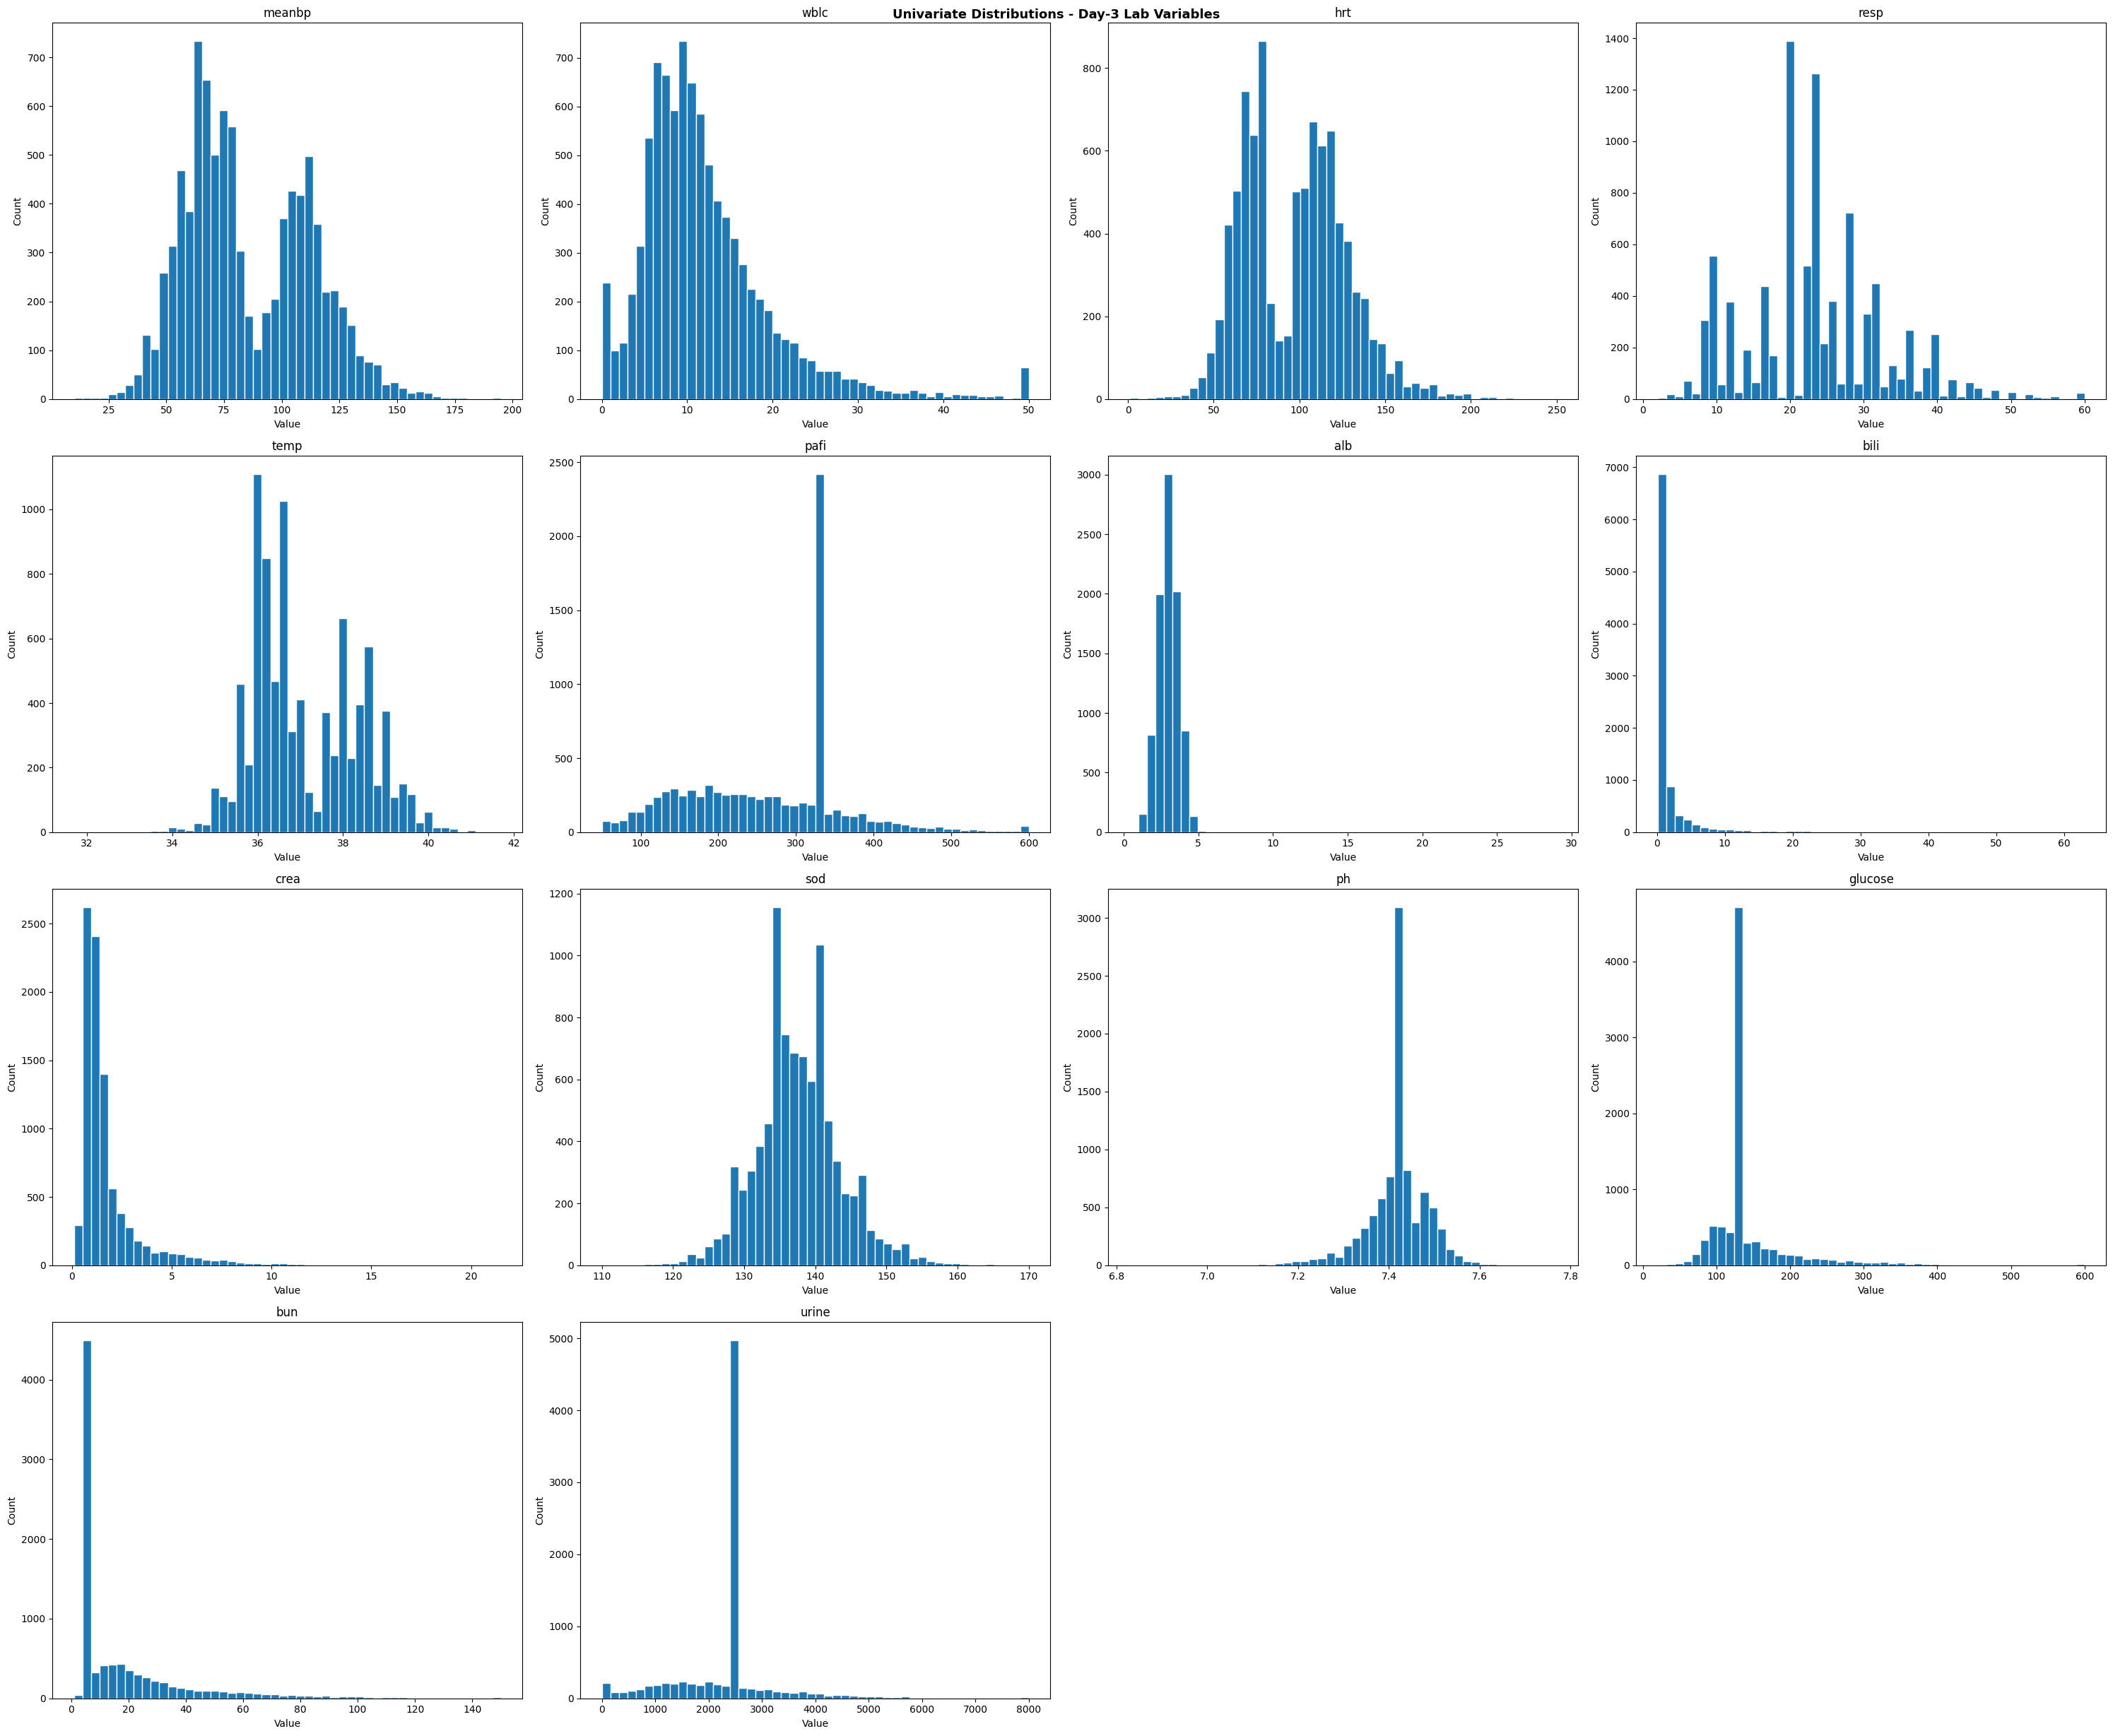

In [35]:
fig, axes = plt.subplots(4, 4, figsize=(30, 25))
for i, col in enumerate(LAB_COLS):
    axes.flat[i].hist(df[col], bins=50, edgecolor="white")
    axes.flat[i].set_title(col)
    axes.flat[i].set_xlabel("Value")
    axes.flat[i].set_ylabel("Count")
for j in range(len(LAB_COLS), len(axes.flat)):
    axes.flat[j].set_visible(False)
fig.suptitle(
    "Univariate Distributions - Day-3 Lab Variables", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

### 3.1 Age follows normal distribution

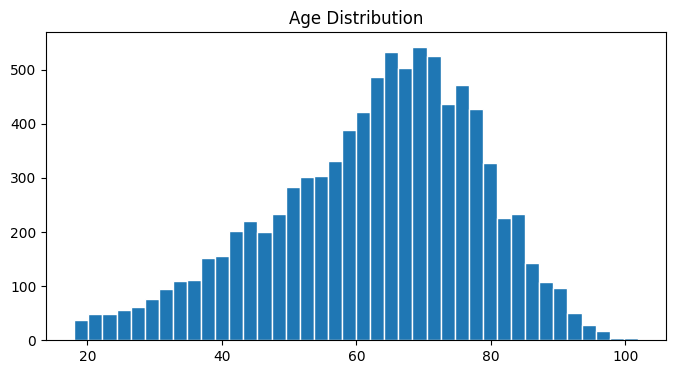

In [36]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["age"], bins=40, edgecolor="white")

ax.set_title("Age Distribution")
plt.show()

---
## Section 4: Bivariate Analysis - Lab Values by Survival Outcome

- Difficult to see any impact these lab values make with this analysis
- The paper did say this only becomes evident when combined with Disease group. For example, a high creatine with kidney failure gives high likelihood of mortality. 

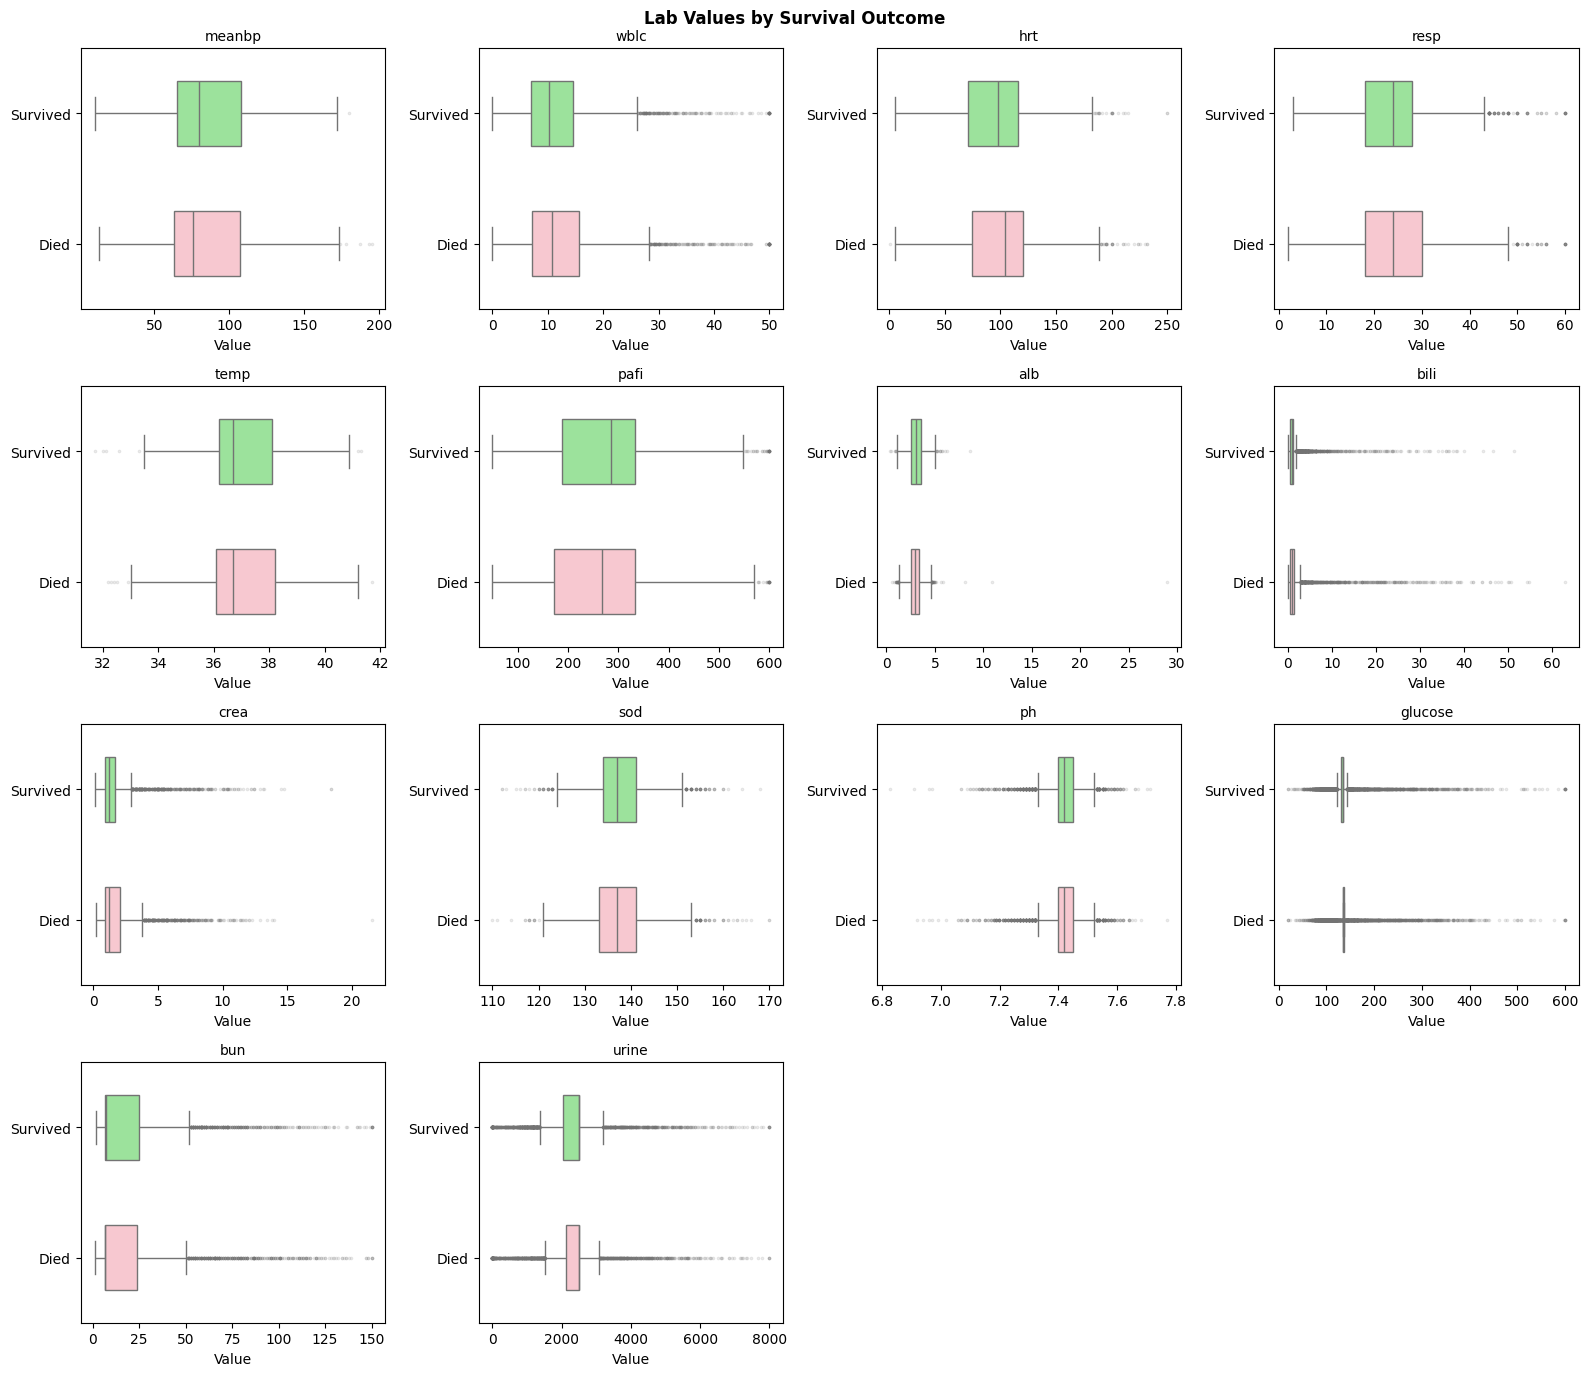

In [37]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
for i, col in enumerate(LAB_COLS):
    ax = axes.flat[i]
    sns.boxplot(
        data=df,
        y=TARGET_COL,
        x=col,
        ax=ax,
        orient="h",
        palette=["lightgreen", "pink"],
        width=0.5,
        flierprops=dict(marker=".", alpha=0.2, markersize=3),
    )
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("Value")
    ax.set_ylabel("")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Survived", "Died"])

for j in range(len(LAB_COLS), len(axes.flat)):
    axes.flat[j].set_visible(False)

fig.suptitle(
    "Lab Values by Survival Outcome",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

---
## Section 5: Demographic Analysis

- Mortality gradual decline as wealth increases
- Asian group a bit more mortality 

In [38]:
def plot_mortality_rate(df, col, target_col, overall_rate, ax, title=None, sort=True):
    rate = df.groupby(col, observed=True)[target_col].mean()
    rate = rate.sort_values(ascending=False)
    bars = ax.bar(
        range(len(rate)),
        rate.values * 100,
        edgecolor="white",
        width=0.6,
    )
    ax.axhline(
        overall_rate * 100,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label=f"Overall ({overall_rate:.1%})",
    )
    ax.set_title(title or f"Mortality Rate by {col}")
    ax.set_ylabel("180-Day Mortality (%)")
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels(rate.index, rotation=30, ha="right", fontsize=8)
    ax.legend(fontsize=8)
    for bar, v in zip(bars, rate.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{v:.1%}",
            ha="center",
            fontsize=8,
        )

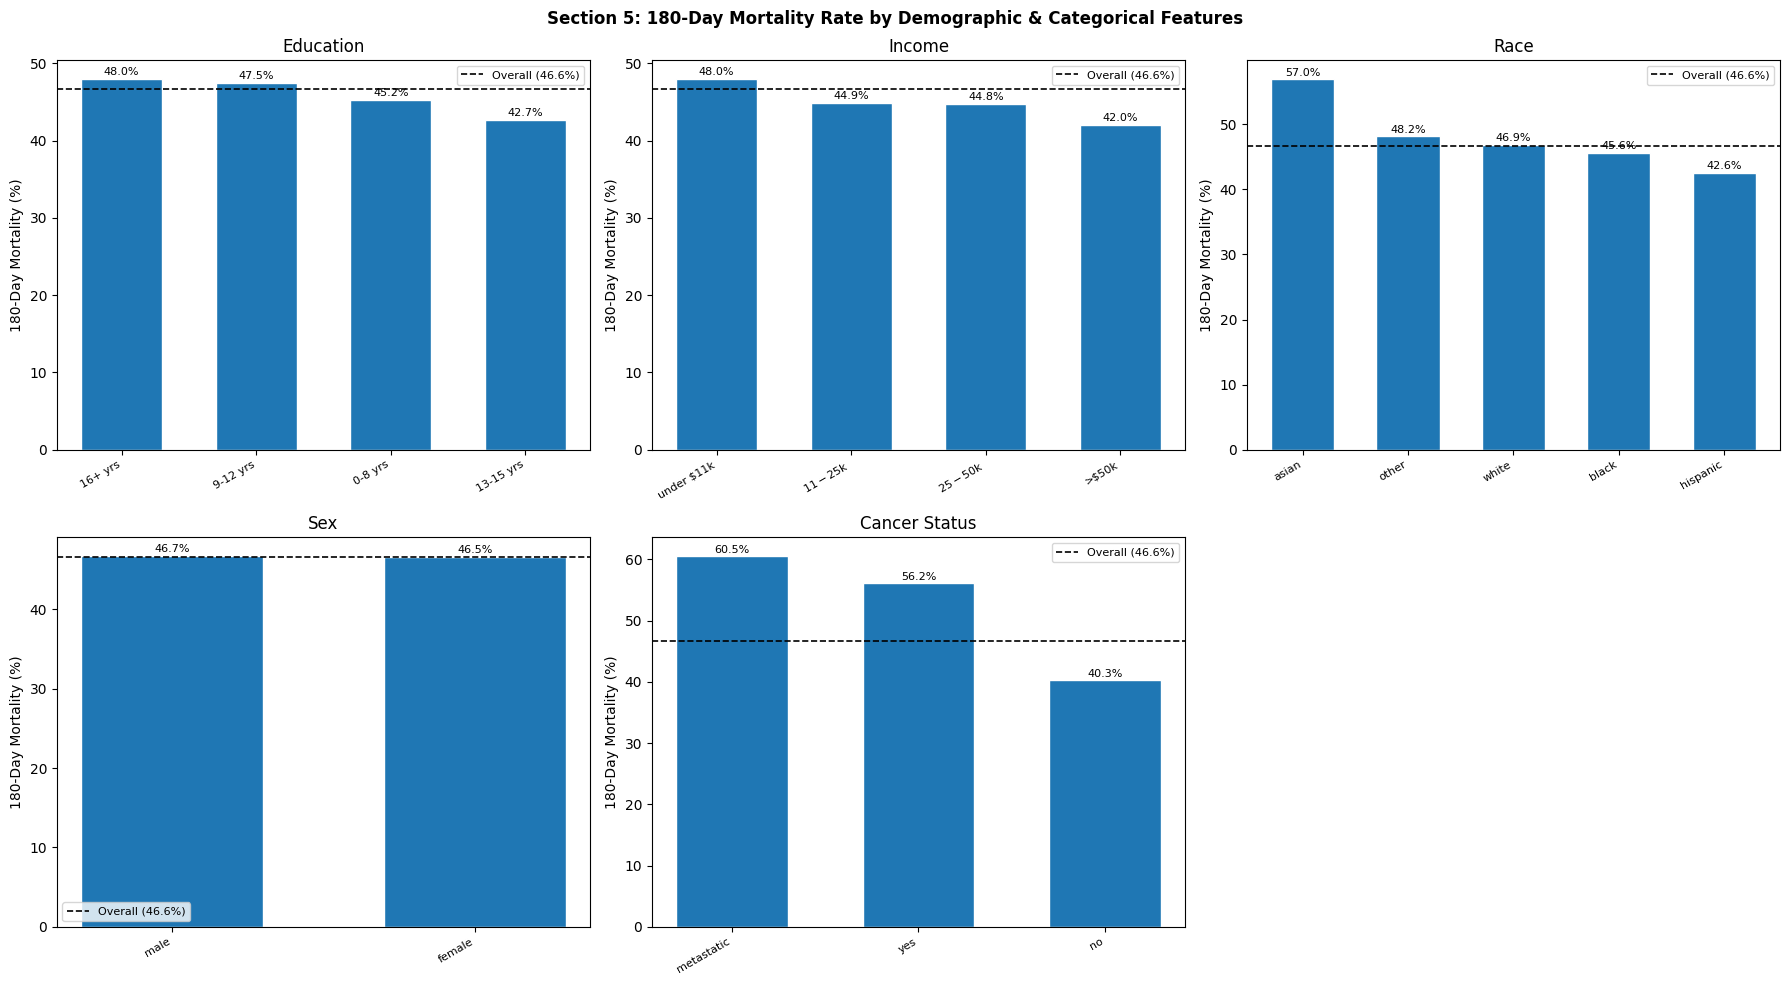

In [39]:
# education bins
edu_bins = [0, 8, 12, 15, 100]
edu_labels = ["0-8 yrs", "9-12 yrs", "13-15 yrs", "16+ yrs"]
df["edu_group"] = pd.cut(df["edu"], bins=edu_bins, labels=edu_labels, right=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_mortality_rate(
    df, "edu_group", TARGET_COL, overall_rate, axes[0, 0], title="Education", sort=False
)
plot_mortality_rate(df, "income", TARGET_COL, overall_rate, axes[0, 1], title="Income")
plot_mortality_rate(df, "race", TARGET_COL, overall_rate, axes[0, 2], title="Race")
plot_mortality_rate(df, "sex", TARGET_COL, overall_rate, axes[1, 0], title="Sex")
plot_mortality_rate(
    df, "ca", TARGET_COL, overall_rate, axes[1, 1], title="Cancer Status"
)
axes[1, 2].set_visible(False)

fig.suptitle(
    "Section 5: 180-Day Mortality Rate by Demographic & Categorical Features",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

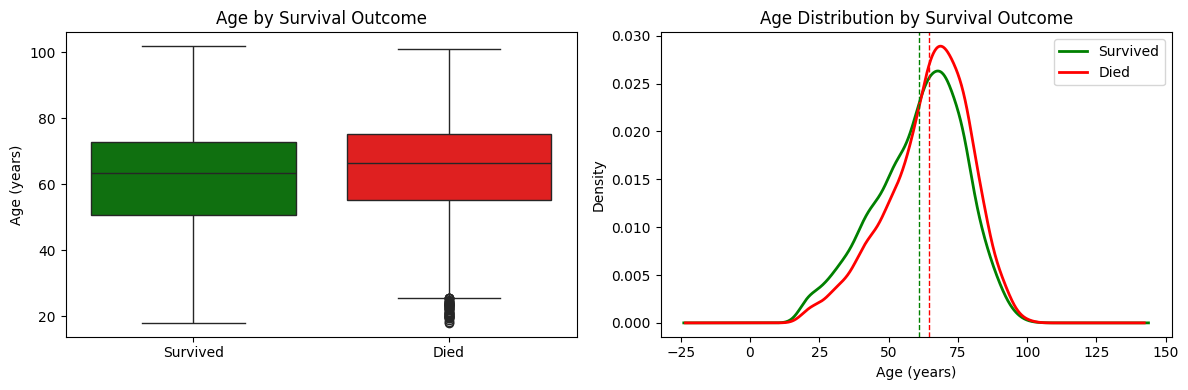

In [40]:
# Survivorship by age
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x=TARGET_COL, y="age", ax=axes[0], palette=["green", "red"])
axes[0].set_title("Age by Survival Outcome")
axes[0].set_xticklabels(["Survived", "Died"])
axes[0].set_xlabel("")
axes[0].set_ylabel("Age (years)")

# KDE overlay
for label, grp, color in [("Survived", survivors, "green"), ("Died", died, "red")]:
    grp["age"].plot.kde(ax=axes[1], label=label, color=color, linewidth=2)
axes[1].axvline(survivors["age"].mean(), color="green", linestyle="--", linewidth=1)
axes[1].axvline(died["age"].mean(), color="red", linestyle="--", linewidth=1)
axes[1].set_title("Age Distribution by Survival Outcome")
axes[1].set_xlabel("Age (years)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Section 6: Disease Group Analysis

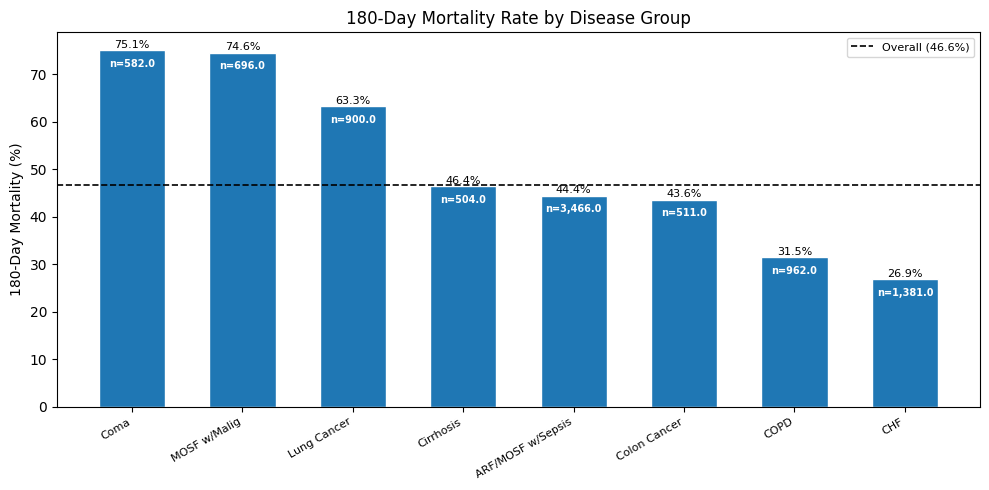

In [41]:
# mortality rate (uses utility) + patient count annotation
grp = df.groupby("dzgroup", observed=True)["death_180d"].agg(["mean", "count"])
grp.columns = ["Mortality", "N"]
grp = grp.sort_values("Mortality", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
plot_mortality_rate(
    df,
    "dzgroup",
    TARGET_COL,
    overall_rate,
    ax,
    title="180-Day Mortality Rate by Disease Group",
)
# annotate patient counts below percentage labels
for i, (_, row) in enumerate(grp.iterrows()):
    ax.text(
        i,
        row["Mortality"] * 100 - 3.5,
        f"n={row['N']:,}",
        ha="center",
        fontsize=7,
        color="white",
        fontweight="bold",
    )
plt.tight_layout()
plt.show()

---
## Section 7: DNR Status

- **no dnr**: no order placed
- **dnr before sadm**:  order existed before study admission
- **dnr after sadm**: order placed during the admission (possibly due to detereorating conditions)


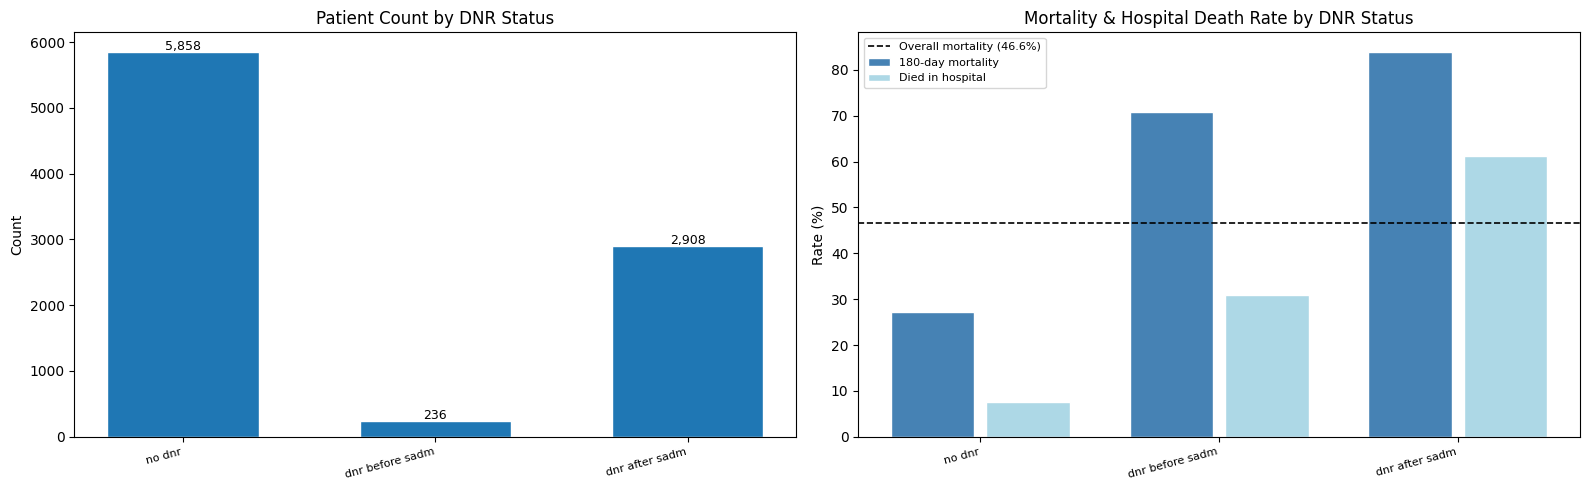

In [42]:
DNR_ORDER = ["no dnr", "dnr before sadm", "dnr after sadm"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

counts = df["dnr"].value_counts().reindex(DNR_ORDER)

# DNR count
axes[0].bar(range(3), counts.values, edgecolor="white", width=0.6)
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(DNR_ORDER, rotation=15, ha="right", fontsize=8)
axes[0].set_title("Patient Count by DNR Status")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f"{v:,}", ha="center", fontsize=9)

# DNR status compare
mort = df.groupby("dnr", observed=True)["death_180d"].mean().reindex(DNR_ORDER)
hosp = df.groupby("dnr", observed=True)["hospdead"].mean().reindex(DNR_ORDER)
x = range(3)

axes[1].bar(
    [i - 0.2 for i in x],
    mort.values * 100,
    width=0.35,
    color="steelblue",
    edgecolor="white",
    label="180-day mortality",
)
axes[1].bar(
    [i + 0.2 for i in x],
    hosp.values * 100,
    width=0.35,
    color="lightblue",
    edgecolor="white",
    label="Died in hospital",
)
axes[1].axhline(
    overall_rate * 100,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Overall mortality ({overall_rate:.1%})",
)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(DNR_ORDER, rotation=15, ha="right", fontsize=8)
axes[1].set_title("Mortality & Hospital Death Rate by DNR Status")
axes[1].set_ylabel("Rate (%)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

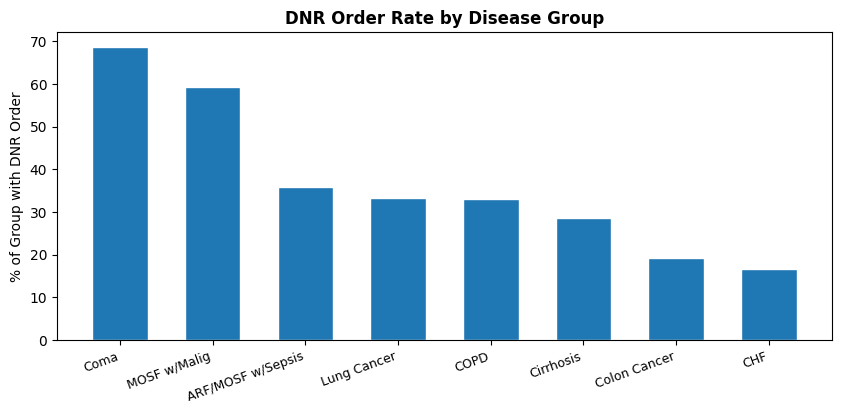

In [43]:
# DNR rate by Disease Group
dnr_rate = (
    df[df["dnr"] != "no dnr"].groupby("dzgroup", observed=True).size()
    / df.groupby("dzgroup", observed=True).size()
)
dnr_rate = dnr_rate.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(
    range(len(dnr_rate)),
    dnr_rate.values * 100,
    edgecolor="white",
    width=0.6,
)
ax.set_xticks(range(len(dnr_rate)))
ax.set_xticklabels(dnr_rate.index, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("% of Group with DNR Order")
ax.set_title("DNR Order Rate by Disease Group", fontweight="bold")
plt.show()

---
## Section 8: Interaction Analysis — Disease Group × Clinical Features

Per Knaus et al. (1995), lab values and demographic factors only become strongly 
predictive of mortality in combination with primary disease group. We examine two 
key interactions identified in the original study:

1. **Albumin × Disease Group** — low albumin was strongly predictive in cancer, 
   COPD, and CHF but relatively unimportant in coma or MOSF
2. **Age × Disease Group** — advancing age heavily impacted COPD survival but 
   had almost no incremental effect in MOSF or malignancy

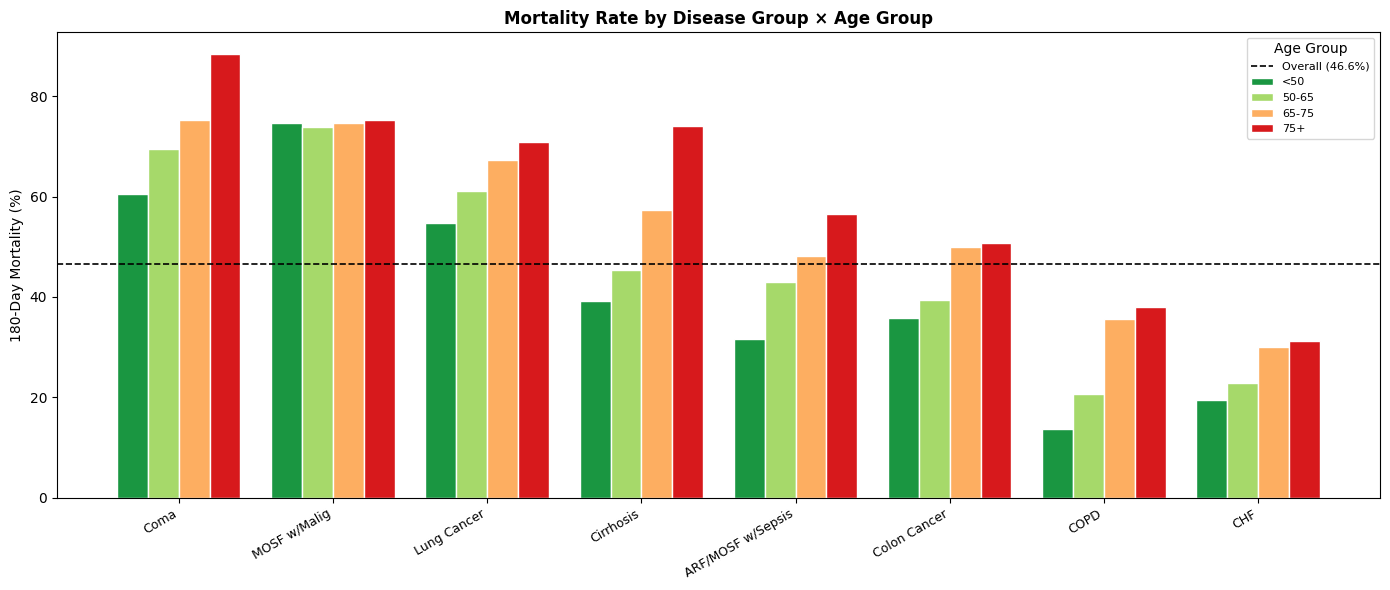

In [44]:
# Create age groups for interaction analysis
age_bins = [0, 50, 65, 75, 120]
age_labels = ["<50", "50-65", "65-75", "75+"]
df["age_group"] = pd.cut(df["age"], bins=age_bins, labels=age_labels)

# --- Plot: Mortality rate by Disease Group × Age Group ---
age_int = (
    df.groupby(["dzgroup", "age_group"], observed=True)["death_180d"]
    .mean()
    .reset_index()
)
age_int.columns = ["dzgroup", "age_group", "mortality_rate"]

dz_order = (
    df.groupby("dzgroup", observed=True)["death_180d"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(dz_order))
width = 0.2
age_groups = ["<50", "50-65", "65-75", "75+"]
colors = ["#1a9641", "#a6d96a", "#fdae61", "#d7191c"]

for i, (age_grp, color) in enumerate(zip(age_groups, colors)):
    subset = age_int[age_int["age_group"] == age_grp]
    subset = subset.set_index("dzgroup").reindex(dz_order)
    ax.bar(
        [xi + (i - 1.5) * width for xi in x],
        subset["mortality_rate"] * 100,
        width=width,
        label=age_grp,
        color=color,
        edgecolor="white",
    )

ax.axhline(
    df["death_180d"].mean() * 100,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Overall ({df['death_180d'].mean():.1%})",
)
ax.set_xticks(list(x))
ax.set_xticklabels(dz_order, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("180-Day Mortality (%)")
ax.set_title(
    "Mortality Rate by Disease Group × Age Group", fontweight="bold", fontsize=12
)
ax.legend(title="Age Group", fontsize=8)
plt.tight_layout()
plt.show()

### 8.1 Interaction: Mortality by Disease Group × Age Group

The chart reveals meaningful variation in how age modifies 180-day mortality 
risk across disease groups, consistent with findings reported by Knaus et al. 
(1995, Appendix Figure 3).

**COPD shows the strongest age gradient.** Younger COPD patients (<50, 50–65) 
fall well below the overall mortality average of 46.8%, while the 65–75 and 75+ 
groups rise noticeably above it. This confirms the Knaus finding that in COPD, 
an increase in age from 70 to 75 years meaningfully increases 180-day mortality 
risk, more so than in any other disease group.

**Coma has high baseline mortality regardless of age.** Even the youngest Coma 
patients (~61%) exceed the overall average, indicating that disease severity 
drives mortality in this group more than age does. A modest amplifying effect 
of age is visible in the 65–75 to 75+ transition (~77% to ~85%), but this is 
secondary to the disease itself.

**MOSF with Malignancy and Lung Cancer show flat age profiles.** Bars are 
relatively uniform across all age groups, consistent with the Knaus finding 
that in acute physiologic crises with malignancy, severity of illness dominates 
prognosis and age adds little incremental risk.

**Cirrhosis and CHF** show moderate age effects with bars trending upward across 
age groups but without the steep gradient seen in COPD.

**Clinical implication:** Age is not uniformly prognostic across disease groups. 
Its predictive value is disease-dependent, strongest in chronic conditions like 
COPD where physiologic reserve declines gradually with age, and weakest in acute 
severe conditions where immediate physiologic status determines outcome. This 
interaction should be explicitly modeled in the full project rather than treating 
age as a global linear predictor.

**Note:** Disease groups are ordered left to right by overall 180-day mortality 
rate (highest to lowest), not by age effect magnitude.

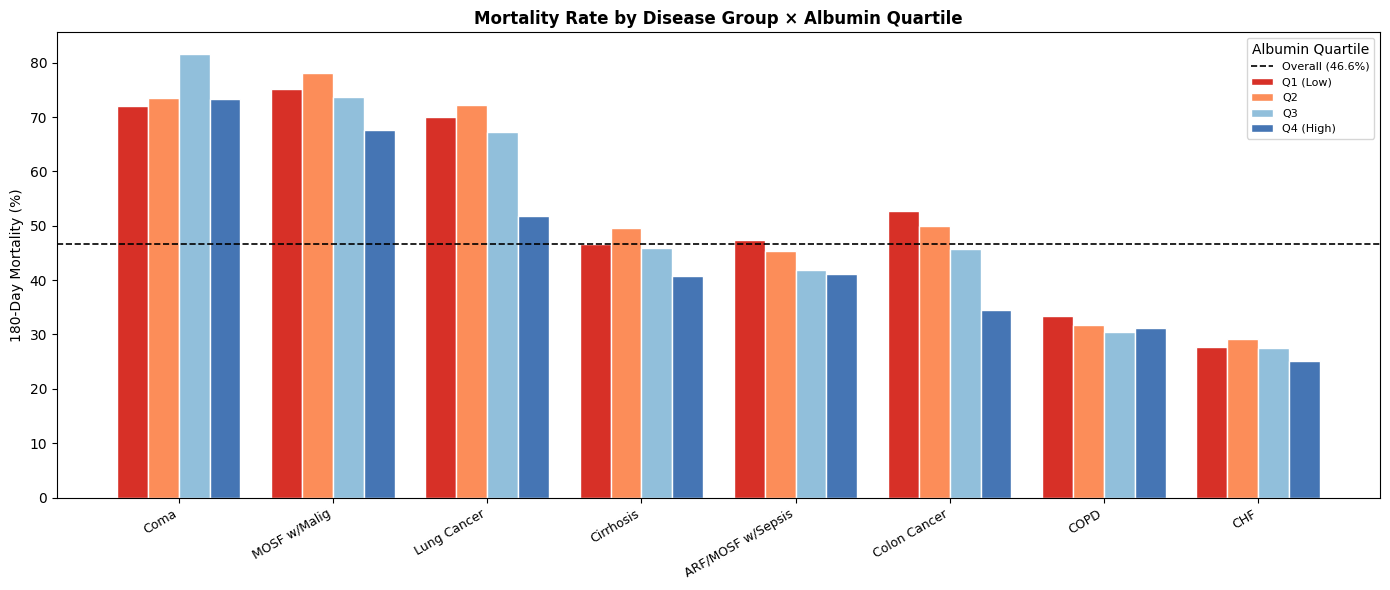

In [45]:
# Create albumin quartile groups
# KNN imputation restored sufficient variation for 4 true quartiles
# Note: original domain fill of 3.5 coincided with Q3 boundary,
# collapsing bins — replaced with KNN imputation in cleaning notebook
df["alb_quartile"] = pd.qcut(
    df["alb"], q=4, labels=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"]
)

# --- Plot: Mortality rate by Disease Group × Albumin Quartile ---
alb_int = (
    df.groupby(["dzgroup", "alb_quartile"], observed=True)["death_180d"]
    .mean()
    .reset_index()
)
alb_int.columns = ["dzgroup", "alb_quartile", "mortality_rate"]

fig, ax = plt.subplots(figsize=(14, 6))
quartiles = ["Q1 (Low)", "Q2", "Q3", "Q4 (High)"]
colors = ["#d73027", "#fc8d59", "#91bfdb", "#4575b4"]

for i, (quartile, color) in enumerate(zip(quartiles, colors)):
    subset = alb_int[alb_int["alb_quartile"] == quartile]
    subset = subset.set_index("dzgroup").reindex(dz_order)
    ax.bar(
        [xi + (i - 1.5) * width for xi in x],
        subset["mortality_rate"] * 100,
        width=width,
        label=quartile,
        color=color,
        edgecolor="white",
    )

ax.axhline(
    df["death_180d"].mean() * 100,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Overall ({df['death_180d'].mean():.1%})",
)
ax.set_xticks(list(x))
ax.set_xticklabels(dz_order, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("180-Day Mortality (%)")
ax.set_title(
    "Mortality Rate by Disease Group × Albumin Quartile", fontweight="bold", fontsize=12
)
ax.legend(title="Albumin Quartile", fontsize=8)
plt.tight_layout()
plt.show()

### 8.2 Interaction: Mortality by Disease Group × Albumin Quartile

Following KNN imputation of albumin (replacing the original domain fill of 3.5 
g/dL which collapsed quartile bins), this chart examines whether serum albumin 
level modifies 180-day mortality risk differently across disease groups, a key 
interaction identified by Knaus et al. (1995).

**Lung Cancer shows the strongest albumin gradient.** Mortality decreases from 
approximately 69% in the lowest albumin quartile (Q1) to 51% in the highest (Q4),
an 18 percentage point spread, the largest gradient in the chart. This directly 
confirms the Knaus finding that low serum albumin had an especially strong 
relation with risk for death in lung cancer patients.

**Colon Cancer shows the second strongest gradient.** Mortality decreases from 
approximately 53% (Q1) to 34% (Q4), a 19 percentage point spread when the full 
range is considered, though the Q1–Q2 step is the most pronounced. Consistent 
with Knaus identifying albumin as strongly prognostic in colon cancer patients.

**CHF and COPD show weak but present albumin gradients**, a modest reduction 
in mortality from low to high albumin quartiles, consistent with the Knaus 
finding of a weaker but present albumin association in chronic conditions.

**ARF/MOSF with Sepsis and Cirrhosis show relatively flat albumin profiles,** 
suggesting albumin adds limited prognostic value in these groups beyond overall 
disease severity.

**Coma shows an unexpected reverse pattern** — Q4 (high albumin) has the highest 
mortality (~81%) rather than the lowest. This counterintuitive finding likely 
reflects confounding: patients in a coma with preserved albumin levels may 
represent a distinct clinical subtype, such as acute neurological events in 
otherwise well-nourished patients. This warrants further investigation in the 
modeling phase.

**MOSF with Malignancy shows a modest reverse pattern** — Q2 is slightly higher 
than Q1 before declining, suggesting albumin's relationship with mortality is 
nonlinear or confounded by disease-specific factors in this group.

**Clinical and modeling implication:** Albumin is not a uniformly useful predictor 
across all disease groups. Its prognostic value is most pronounced in cancer 
patients, particularly lung and colon cancer, and largely absent or reversed in 
acute physiologic crises. The full project model should include albumin × disease 
group interaction terms rather than treating albumin as a global linear predictor, 
consistent with the original SUPPORT prognostic model (Knaus et al., 1995).

**Methodological note:** Albumin was re-imputed using KNN (k=5) with 
physiologically related features as neighbors (age, meanbp, hrt, resp, temp, 
sod), replacing the original domain fill value of 3.5 g/dL. The KNN approach 
produced a clinically coherent distribution (median = 2.96 g/dL, IQR = 
2.50–3.40), consistent with expected albumin levels in a critically ill 
population.

---
## Section 9: Benchmark Evaluation — SUPPORT Model vs. Actual 180-Day Mortality

The SUPPORT prognostic model (Knaus et al., 1995) generated individualized 
6-month survival probability estimates (`surv6m`) for each patient at study 
day 3. A central objective of this project is to compare our classification 
model's performance against this benchmark.

Before building our model, we first establish how well the SUPPORT estimates 
discriminate between patients who died within 180 days and those who survived. 
Three evaluations are performed:

1. **Distribution** — do the SUPPORT survival estimates separate the two 
   outcome groups?
2. **ROC curve and AUC** — how well does the SUPPORT model rank patients by 
   mortality risk? Knaus et al. reported an AUC of 0.78 on phase II validation 
   data; we evaluate whether this holds in our dataset.
3. **Calibration** — do the predicted survival probabilities match actual 
   survival rates across the full probability range?

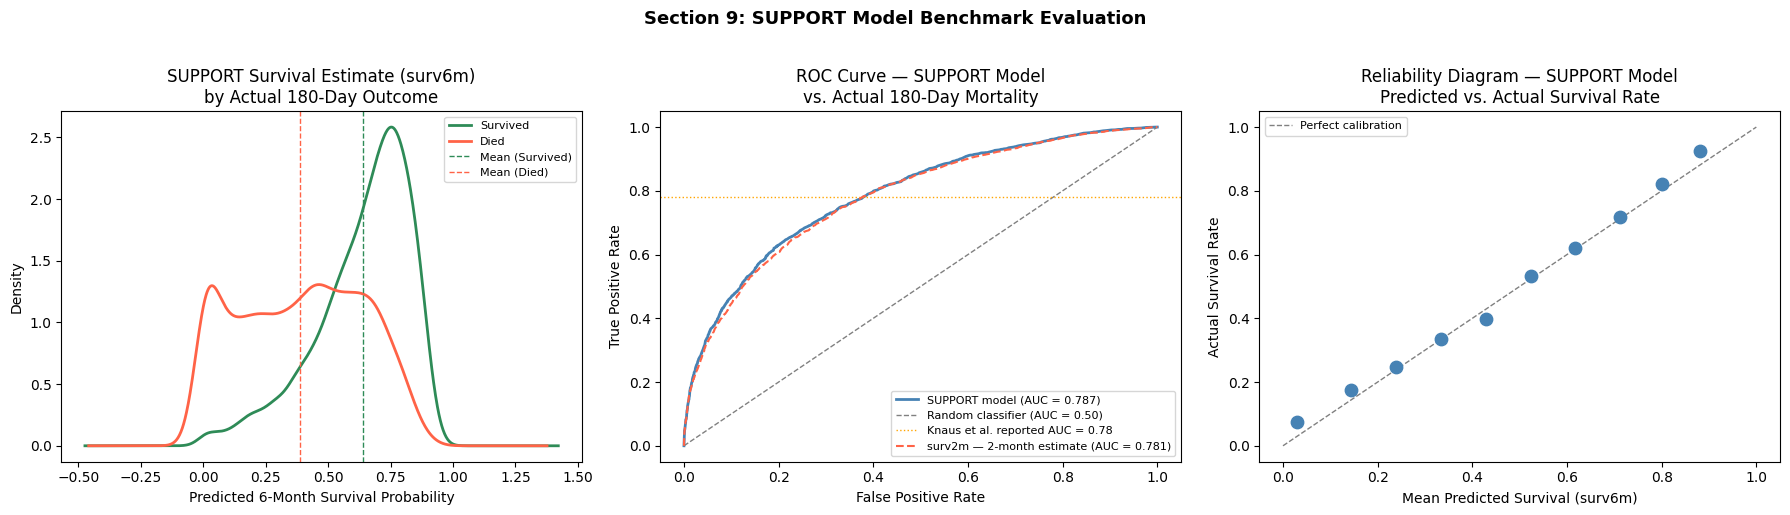

SUPPORT model AUC: 0.787
Knaus et al. reported AUC: 0.780

Mean surv6m — Survived: 0.640
Mean surv6m — Died:     0.389

Overall actual survival rate: 0.534
Overall mean surv6m:          0.523

surv6m AUC: 0.787
surv2m AUC: 0.781


In [54]:
# Section 9: Benchmark Comparison — SUPPORT Model vs. Actual 180-Day Mortality
#
# The SUPPORT model produced physician-facing survival probability estimates
# (surv6m) for each patient. We evaluate how well these estimates discriminate
# between patients who died within 180 days and those who survived, using:
#
# 1. Distribution plot — surv6m by actual outcome
# 2. ROC curve — with AUC for direct comparison to Knaus et al. (1995)
#    reported AUC of 0.78
# 3. Calibration check — mean predicted survival vs. actual survival rate

from sklearn.metrics import roc_curve, roc_auc_score

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: surv6m distribution by actual outcome ---
for label, grp, color in [
    ("Survived", df[df["death_180d"] == 0], "seagreen"),
    ("Died", df[df["death_180d"] == 1], "tomato"),
]:
    grp["surv6m"].plot.kde(ax=axes[0], label=label, color=color, linewidth=2)

axes[0].axvline(
    df[df["death_180d"] == 0]["surv6m"].mean(),
    color="seagreen",
    linestyle="--",
    linewidth=1,
    label="Mean (Survived)",
)
axes[0].axvline(
    df[df["death_180d"] == 1]["surv6m"].mean(),
    color="tomato",
    linestyle="--",
    linewidth=1,
    label="Mean (Died)",
)
axes[0].set_title("SUPPORT Survival Estimate (surv6m)\nby Actual 180-Day Outcome")
axes[0].set_xlabel("Predicted 6-Month Survival Probability")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=8)

# --- Plot 2: ROC curve ---
# Note: surv6m is probability of SURVIVAL so we invert for death prediction
fpr, tpr, _ = roc_curve(df["death_180d"], 1 - df["surv6m"])
auc = roc_auc_score(df["death_180d"], 1 - df["surv6m"])

axes[1].plot(
    fpr, tpr, color="steelblue", linewidth=2, label=f"SUPPORT model (AUC = {auc:.3f})"
)
axes[1].plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle="--",
    linewidth=1,
    label="Random classifier (AUC = 0.50)",
)
axes[1].axhline(
    0.78,
    color="orange",
    linestyle=":",
    linewidth=1,
    label="Knaus et al. reported AUC = 0.78",
)
axes[1].set_title("ROC Curve — SUPPORT Model\nvs. Actual 180-Day Mortality")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")

fpr2m, tpr2m, _ = roc_curve(df["death_180d"], 1 - df["surv2m"])
auc2m = roc_auc_score(df["death_180d"], 1 - df["surv2m"])
axes[1].plot(
    fpr2m,
    tpr2m,
    color="tomato",
    linewidth=1.5,
    linestyle="--",
    label=f"surv2m — 2-month estimate (AUC = {auc2m:.3f})",
)

# Legend called last so all lines are included
axes[1].legend(fontsize=8)

# --- Plot 3: Calibration ---
# Bin patients by predicted survival probability and compare to actual survival
df["surv6m_bin"] = pd.cut(df["surv6m"], bins=10)
calibration = (
    df.groupby("surv6m_bin", observed=True)
    .agg(
        mean_predicted=("surv6m", "mean"),
        actual_survival=("death_180d", lambda x: 1 - x.mean()),
    )
    .dropna()
)

axes[2].scatter(
    calibration["mean_predicted"],
    calibration["actual_survival"],
    color="steelblue",
    s=80,
    zorder=3,
)
axes[2].plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle="--",
    linewidth=1,
    label="Perfect calibration",
)
axes[2].set_title(
    "Reliability Diagram — SUPPORT Model\nPredicted vs. Actual Survival Rate"
)
axes[2].set_xlabel("Mean Predicted Survival (surv6m)")
axes[2].set_ylabel("Actual Survival Rate")
axes[2].legend(fontsize=8)

plt.suptitle(
    "Section 9: SUPPORT Model Benchmark Evaluation",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

# Summary stats
print(f"SUPPORT model AUC: {auc:.3f}")
print(f"Knaus et al. reported AUC: 0.780")
print(f"\nMean surv6m — Survived: {df[df['death_180d']==0]['surv6m'].mean():.3f}")
print(f"Mean surv6m — Died:     {df[df['death_180d']==1]['surv6m'].mean():.3f}")
print(f"\nOverall actual survival rate: {1 - df['death_180d'].mean():.3f}")
print(f"Overall mean surv6m:          {df['surv6m'].mean():.3f}")
print(f"\nsurv6m AUC: {auc:.3f}")
print(f"surv2m AUC: {auc2m:.3f}")

### 9.1 Benchmark Evaluation Results

**Distribution of SUPPORT Predictions by Actual Outcome**

The SUPPORT model assigned meaningfully different survival probabilities to 
patients who survived versus those who died. Survivors received a mean predicted 
survival probability of 0.640, while patients who died received a mean of 0.389 
— a separation of 0.251. The distributions overlap substantially in the 0.3–0.7 
range, reflecting the inherent uncertainty in predicting outcomes for patients 
with moderate risk profiles. The x-axis extends slightly beyond the valid 0–1 
probability range at both extremes due to kernel density smoothing, not real 
data values.

**Discrimination — ROC Curve and AUC**

The ROC curve plots two independently calculated metrics across all possible 
decision thresholds:

- **True Positive Rate (y-axis):** of all patients who actually died, what 
  fraction did the model correctly identify as high risk?
- **False Positive Rate (x-axis):** of all patients who actually survived, 
  what fraction did the model incorrectly flag as high risk?

Each point on the curve represents one threshold setting, showing the 
simultaneous tradeoff between catching actual deaths and generating false 
alarms. The two metrics have no direct mathematical relationship; they are 
calculated from entirely separate patient groups and plotted together to 
visualize the tradeoff as the threshold moves from 0 to 1.

The area under the curve (AUC) summarizes this tradeoff in a single number: 
the probability that the model ranks a randomly chosen patient who died as 
higher risk than a randomly chosen patient who survived. An AUC of 0.787 
means the SUPPORT model makes this correct ranking approximately 79% of the 
time, replicating Knaus et al.'s reported AUC of 0.78 on independent phase 
II validation data with remarkable fidelity across 30 years and a different 
sample. This consistency also serves as indirect validation that our target 
variable construction and cleaning approach are methodologically sound.

AUC is a threshold-agnostic metric; it does not indicate which specific 
threshold to use clinically, nor does it reflect performance at any single 
operating point. For clinical decision making, where the cost of missing a 
death typically exceeds the cost of a false alarm, precision-recall analysis 
at a specific threshold is more informative. This will be addressed in the 
modeling notebook.

**Reliability — Predicted vs. Actual Survival**

The reliability diagram assesses whether the SUPPORT model's probability 
estimates are trustworthy in absolute terms; when the model assigns a 70% 
survival probability, do approximately 70% of those patients actually survive? 
This is distinct from discrimination: a model can rank patients correctly 
(high AUC) while producing poorly calibrated probabilities, or vice versa.

The dots closely follow the perfect calibration diagonal across the full 
probability range, indicating the SUPPORT model's survival estimates are 
reliable in absolute terms. The overall mean predicted survival (0.523) 
closely matches the actual survival rate (0.534), a gap of only 1.1 
percentage points, confirming good global calibration.

Note that this is a calibration *assessment*, not a recalibration step. 
No correction to the model's probabilities has been applied. Formal 
calibration metrics (Brier score, Hosmer-Lemeshow test) will be computed 
for our own model in the modeling notebook.

**Benchmark Summary**

The SUPPORT model demonstrates both strong discrimination (AUC = 0.787) and 
reliable probability estimates across the full risk range. This establishes 
a meaningful performance benchmark: our classification model must approach 
or exceed AUC = 0.787 to be considered competitive with the original SUPPORT 
prognostic model. Combined discrimination and calibration performance will 
be the primary basis for that comparison.

**surv2m vs. surv6m Discrimination**

The 2-month survival estimate (`surv2m`) was evaluated alongside `surv6m` 
as an additional benchmark. Despite measuring a different time horizon, 
`surv2m` produced a nearly identical AUC of 0.781 — a difference of 0.006 
from `surv6m`. The two ROC curves are visually indistinguishable. This 
confirms the high correlation between the two estimates (r = 0.960) observed 
in the correlation matrix and formally justifies the use of `surv6m` as the 
primary benchmark — not because `surv2m` performs meaningfully worse, but 
because `surv6m` directly aligns with our 180-day target window.

---
## Section 10: Correlation Matrix — Numeric Features

With 46 variables available for modeling, multicollinearity is a meaningful 
risk. Highly correlated features provide redundant information and can 
destabilize model coefficients, inflate standard errors, and complicate 
interpretation. This section identifies problematic feature pairs before 
modeling begins.

The correlation matrix displays Pearson correlations between all numeric 
features. Values close to 1.0 indicate strong positive correlation, values 
close to -1.0 indicate strong negative correlation, and values near 0 
indicate little linear relationship. Pairs with |r| > 0.7 are flagged as 
candidates for feature selection or dimensionality reduction in the modeling 
notebook.

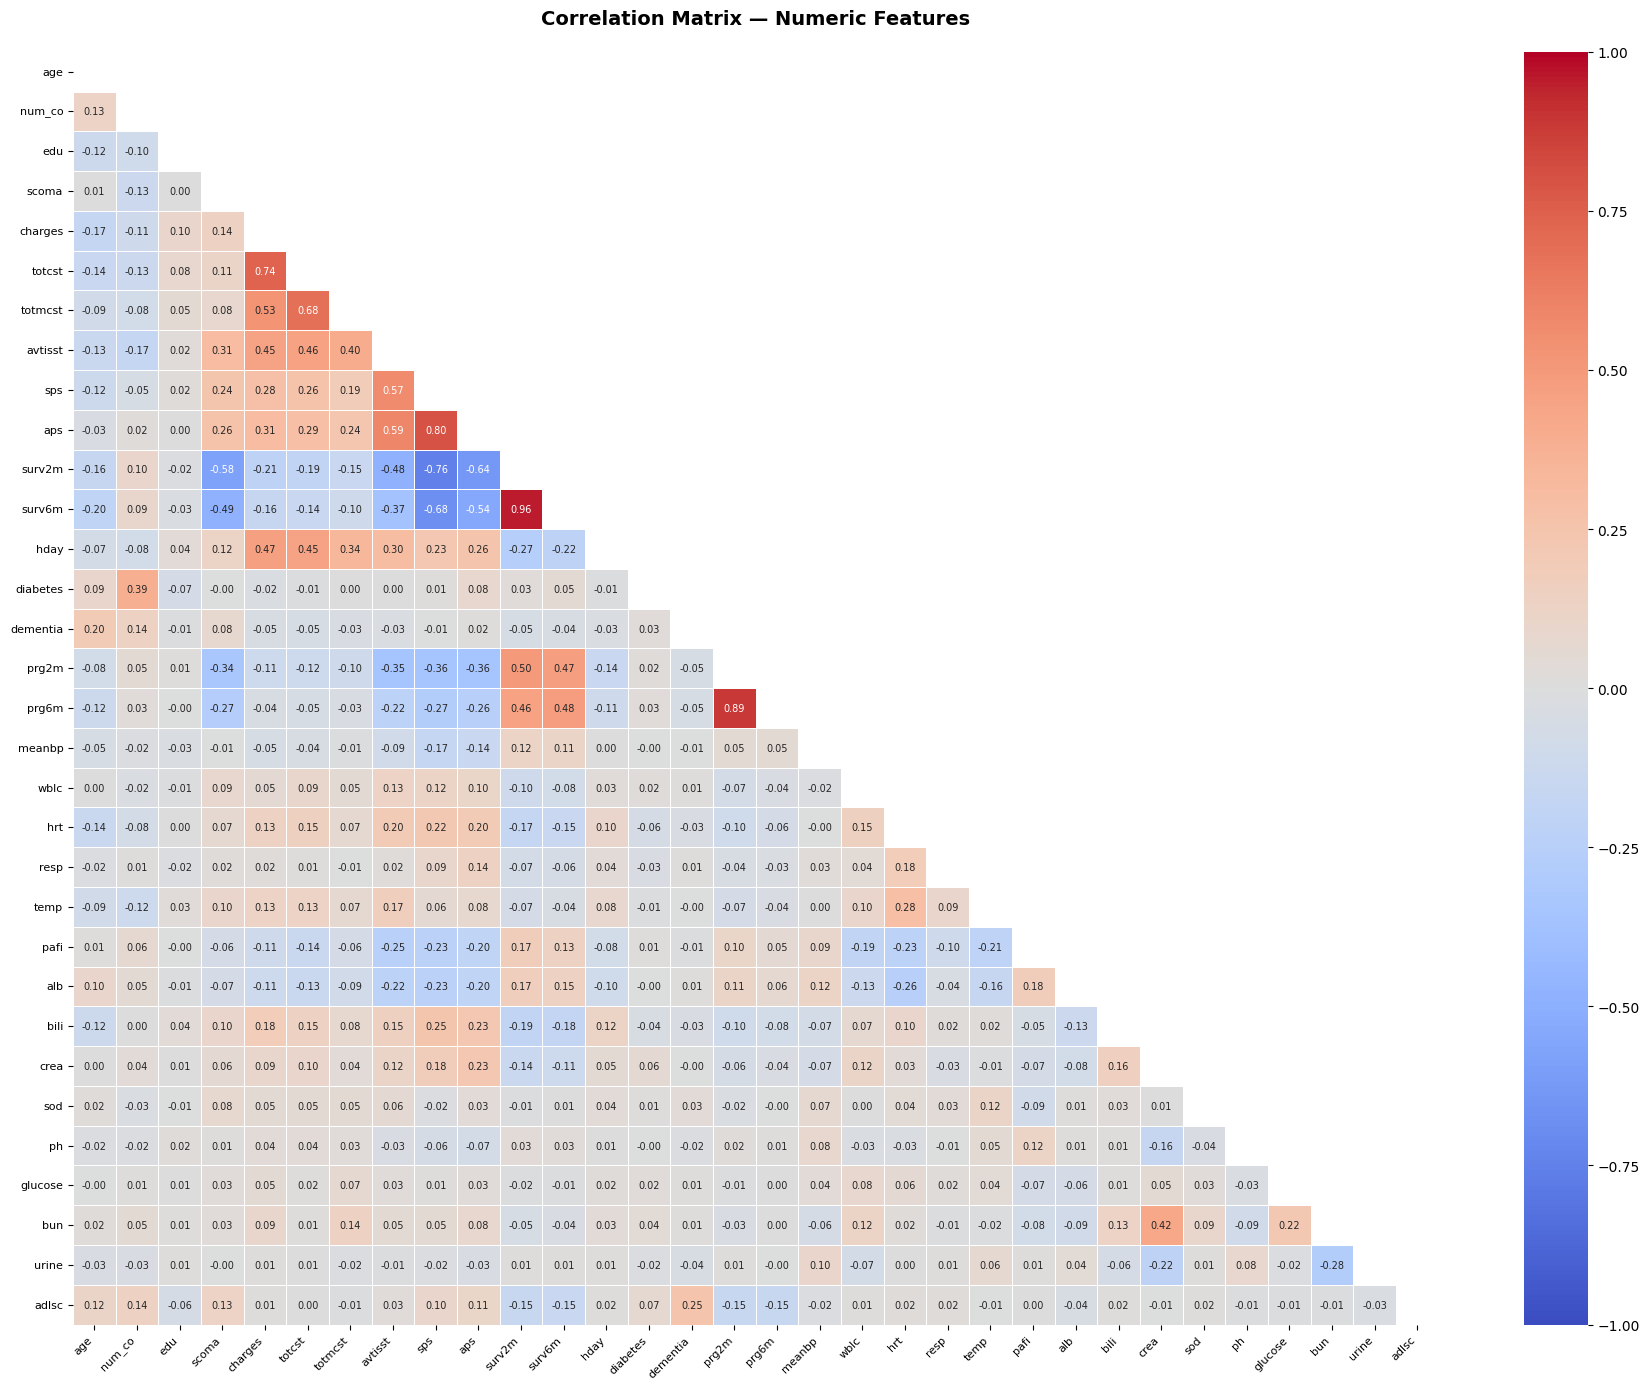

=== High Correlation Pairs (|r| > 0.7) ===

Feature A Feature B      r
   surv6m    surv2m  0.960
    prg6m     prg2m  0.889
      aps       sps  0.800
   totcst   charges  0.742
   surv2m       sps -0.756


In [48]:
# Section 10: Correlation Heatmap — Numeric Features
#
# With 40+ potential predictors, multicollinearity is a real risk.
# Highly correlated features (|r| > 0.7) provide redundant information
# and can destabilize model coefficients. This heatmap identifies
# problematic pairs before modeling begins.

numeric_cols = df.select_dtypes(include="number").columns.tolist()

# Exclude target, outcome, and identifier columns
exclude = ["death_180d", "death", "hospdead", "id", "slos", "d_time"]
feature_cols = [c for c in numeric_cols if c not in exclude]

corr_matrix = df[feature_cols].corr()

# Mask upper triangle for cleaner reading
import numpy as np

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={"size": 7},
    ax=ax,
)
ax.set_title(
    "Correlation Matrix — Numeric Features", fontsize=14, fontweight="bold", pad=20
)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Flag high correlation pairs
print("=== High Correlation Pairs (|r| > 0.7) ===\n")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append(
                {
                    "Feature A": corr_matrix.columns[i],
                    "Feature B": corr_matrix.columns[j],
                    "r": round(r, 3),
                }
            )

if high_corr:
    high_corr_df = pd.DataFrame(high_corr).sort_values("r", ascending=False)
    print(high_corr_df.to_string(index=False))
else:
    print("No pairs with |r| > 0.7 found.")

### 10.1 Correlation Findings

The majority of numeric features are weakly correlated with one another 
(|r| < 0.5), indicating the feature set is generally clean and suitable 
for modeling. Five pairs exceed the |r| > 0.7 multicollinearity threshold 
and warrant specific attention.

**`surv6m` × `surv2m` (r = 0.960)** — the strongest correlation in the 
matrix. Both are SUPPORT model survival probability estimates differing 
only in time horizon (6-month vs. 2-month). They are measuring the same 
underlying construct from the same model inputs, making them functionally 
redundant as predictors. `surv2m` should be excluded from the feature set; 
`surv6m` is retained as the benchmark comparison variable and excluded from 
model features to avoid leakage.

**`prg6m` × `prg2m` (r = 0.889)** — physician survival estimates at 6 and 
2 months respectively. The same redundancy applies as with the SUPPORT 
estimates; both capture physician judgment about the same patient at the 
same point in time. `prg2m` should be excluded; `prg6m` retained if 
physician estimates are included as a feature, noting that combining 
physician estimates with model features replicates the physician-enhanced 
SUPPORT model described in Knaus et al. (1995).

**`aps` × `sps` (r = 0.800)** — both are composite physiologic severity 
scores constructed from overlapping input variables including blood pressure, 
heart rate, respiratory rate, temperature, and laboratory values. Their 
correlation reflects shared measurement of the same underlying construct 
(severity of acute illness) rather than any methodological dependency. Unlike 
the survival estimate pairs, `aps` and `sps` apply different disease-specific 
weightings and are not perfectly interchangeable. Both are retained as 
candidates for the feature set; LASSO regularization in the modeling phase 
will naturally downweight the less informative of the two.

**`totcst` × `charges` (r = 0.742)** — total cost and hospital charges are 
financially related by definition. More importantly, both are outcomes of 
care delivery rather than clinical predictors of mortality; a patient does 
not incur charges because they are sick...they incur charges because of 
interventions performed. Including either as a model feature would introduce 
reverse causality. Both should be excluded from the feature set entirely.

**`surv2m` × `sps` (r = -0.756)** — a strong negative correlation between 
the 2-month survival estimate and the physiology severity score. This is 
clinically expected and not a multicollinearity concern; sicker patients 
(higher sps) receive lower survival probability estimates. The negative sign 
confirms the directionality is correct. No action required.

**Modeling implications:** Three actions follow from this analysis:
1. Drop `surv2m` and `prg2m` — redundant with their 6-month counterparts
2. Drop `totcst` and `charges` — outcomes of care, not predictors
3. Monitor `aps` and `sps` — retain both but apply LASSO regularization 
   to manage their shared variance in the modeling notebook

---
## Section 11: Numeric Feature Summary by Outcome Group

The following table presents mean values of key clinical variables stratified 
by 180-day mortality outcome. Features are ordered by the absolute difference 
between groups, highlighting which variables show the strongest univariate 
separation between survivors and patients who died.

This table serves two purposes: it provides a reportable summary of group 
differences for the technical report, and it establishes the basis for formal 
hypothesis testing in Section 11.1, where statistical significance of each 
difference is evaluated.

In [55]:
# Section 11: Numeric Summary by Outcome Group
#
# Mean values of key clinical variables broken out by 180-day mortality outcome.
# Differences between groups provide univariate signal of predictive importance
# and serve as the basis for formal hypothesis testing in Section 11.1.

key_features = [
    "age",
    "num_co",
    "scoma",
    "sps",
    "aps",
    "meanbp",
    "hrt",
    "resp",
    "temp",
    "alb",
    "bili",
    "crea",
    "sod",
    "ph",
    "glucose",
    "bun",
    "wblc",
    "pafi",
    "urine",
    "adlsc",
]

summary = df.groupby("death_180d")[key_features].mean().T
summary.columns = ["Survived (0)", "Died (1)"]
summary["Difference"] = summary["Died (1)"] - summary["Survived (0)"]
summary["Abs Difference"] = summary["Difference"].abs()
summary = summary.sort_values("Abs Difference", ascending=False)
summary = summary.drop(columns="Abs Difference")
summary = summary.round(3)

print("=== Numeric Feature Means by 180-Day Mortality Outcome ===\n")
print(summary.to_string())

=== Numeric Feature Means by 180-Day Mortality Outcome ===

         Survived (0)  Died (1)  Difference
urine        2367.584  2352.697     -14.887
scoma           5.932    18.345      12.413
aps            32.056    43.437      11.381
pafi          268.739   258.403     -10.336
sps            22.517    28.506       5.989
hrt            95.897   100.471       4.575
age            61.085    64.492       3.407
meanbp         86.557    83.616      -2.941
bili            1.741     2.533       0.792
wblc           11.679    12.457       0.778
adlsc           1.553     2.270       0.718
resp           23.169    23.870       0.701
glucose       146.815   147.364       0.549
bun            19.635    20.151       0.516
crea            1.671     1.848       0.176
alb             3.039     2.927      -0.112
sod           137.590   137.513      -0.077
temp           37.073    37.132       0.058
num_co          1.886     1.851      -0.035
ph              7.418     7.417      -0.001
